Loaded: (43405, 70)

Grade-level default rates (from NB03):
system_grade
AAA    0.0053
AA     0.0078
A      0.0132
BBB    0.0220
BB     0.0424
B      0.0923
CCC    0.1815
Name: default, dtype: float64

Override direction counts:
override_direction
none         28125
downgrade     9012
upgrade       6268
Name: count, dtype: int64

Default rate by override direction:


,n,default_rate
override_direction,,
none,28125,0.0486
upgrade,6268,0.0769
downgrade,9012,0.0270



Pattern check (upgrade > none > downgrade):
  upgrade (0.0769) > none (0.0486): PASS
  none (0.0486) > downgrade (0.0270): PASS


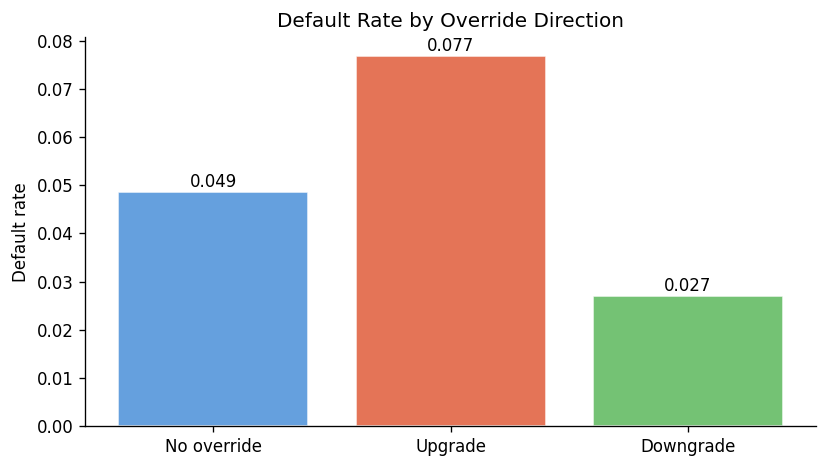

Figure saved: 06_default_by_override.png

Default rate by grade_diff (override cases only):
  negative = upgrade, positive = downgrade


,n,default_rate
grade_diff,,
-2,1752,0.0885
-1,4359,0.0750
0,486,0.1276
1,6394,0.0233
2,2289,0.0140


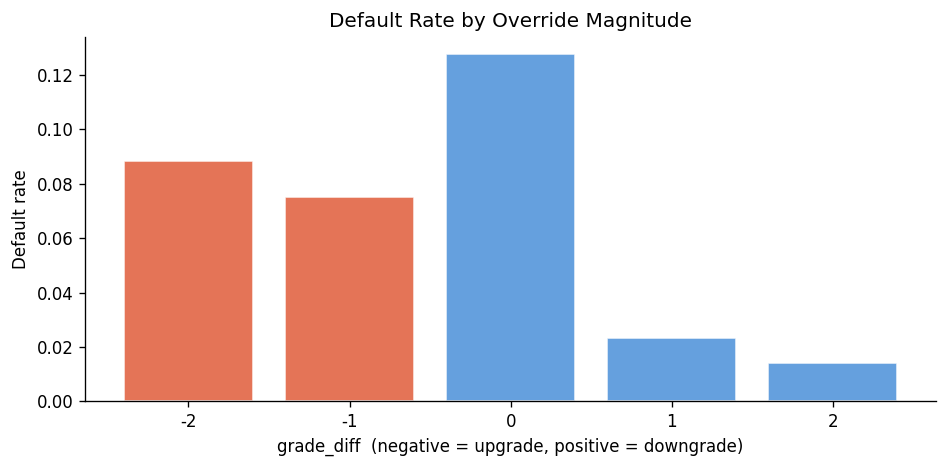

Figure saved: 06b_default_by_grade_diff.png


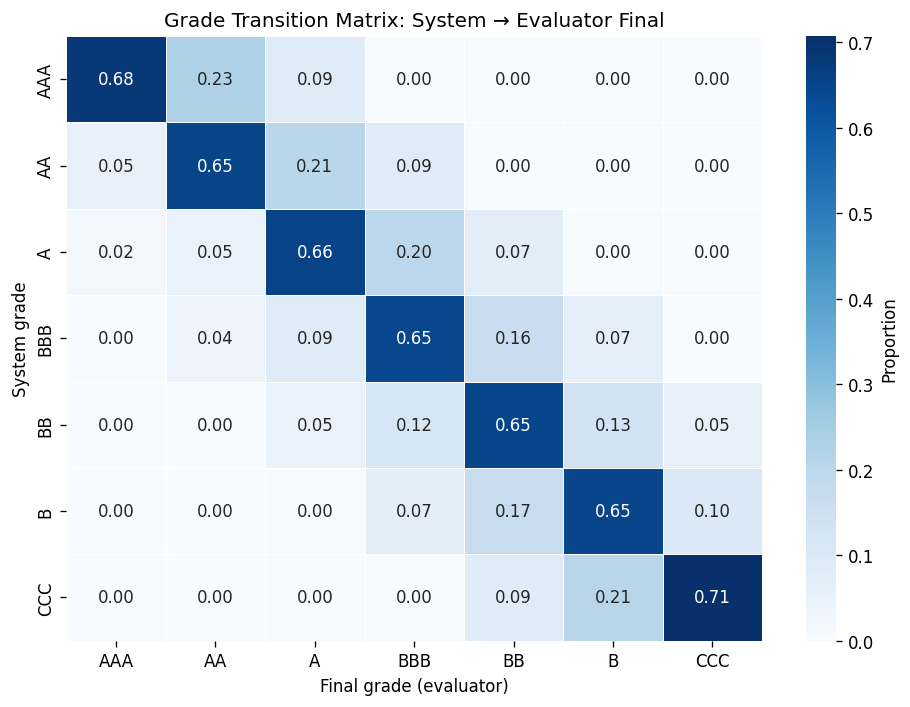

Figure saved: 07_grade_transition_matrix.png
Override simulation summary:


,value
total_companies,43405.0000
override_count,15280.0000
override_rate,0.3520
upgrade_count,6268.0000
downgrade_count,9012.0000
default_rate_none,0.0486
default_rate_upgrade,0.0769
default_rate_downgrade,0.0270


Saved: ../results/tables/04_override_summary.csv
Saved : ../data/processed/override_data.parquet
Shape : (43405, 75)

New columns added:
   override_flag override_direction final_grade  final_ordinal  grade_diff
0              0               none           A              2           0
1              0               none         BBB              3           0
2              1          downgrade         BBB              3           1
3              1          downgrade         BBB              3           1
4              1          downgrade          BB              4           1
5              1          downgrade           B              5           2
6              0               none         AAA              0           0
7              0               none          BB              4           0
8              0               none         BBB              3           0
9              0               none          BB              4           0


In [4]:
# NB04_override_simulation.ipynb

# %% [markdown]
# # NB04 – Evaluator Override Simulation
# **Purpose:** Simulate the evaluator adjustment step.
#
# **Key design principle:**
# Upgrade probability is concentrated in higher-risk grades (B, CCC),
# reflecting the real-world observation that evaluators tend to give
# benefit-of-the-doubt to firms with weak financials based on
# non-financial factors (management quality, collateral, restructuring plans).
# This is independent of pd_system — the upgrade decision is based on
# grade category rules, not the model score.
#
# **Simulation scenario:**
# - 35 % of companies receive an override
# - Upgrade probability by grade:
#     CCC : 0.80  (distressed firms most likely to receive benefit-of-the-doubt)
#     B   : 0.70  (weak firms often upgraded on qualitative grounds)
#     BB  : 0.50  (borderline, mixed judgment)
#     BBB : 0.35  (near investment-grade, modest upgrade pressure)
#     A   : 0.20
#     AA  : 0.15
#     AAA : 0.10  (already top-rated, rarely upgraded)
# - Override magnitude: 1 notch (70 %) or 2 notches (30 %)
#
# **Input:**  `data/processed/graded_data.parquet`
# **Output:**
# - `data/processed/override_data.parquet`
# - `results/figures/06_default_by_override.png`
# - `results/figures/06b_default_by_grade_diff.png`
# - `results/figures/07_grade_transition_matrix.png`
# - `results/tables/04_override_summary.csv`

# %%
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
np.random.seed(2024)

plt.rcParams.update({
    "figure.dpi"       : 120,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})

PROC_DIR  = "../data/processed/"
FIG_DIR   = "../results/figures/"
TABLE_DIR = "../results/tables/"

graded = pd.read_parquet(PROC_DIR + "graded_data.parquet")
print(f"Loaded: {graded.shape}")

GRADE_LABELS = ["AAA", "AA", "A", "BBB", "BB", "B", "CCC"]
GRADE_ORDER  = {g: i for i, g in enumerate(GRADE_LABELS)}
INV_GRADE    = {v: k for k, v in GRADE_ORDER.items()}

# Grade-level default rates (from NB03 results) for reference
print("\nGrade-level default rates (from NB03):")
print(graded.groupby("system_grade")["default"]
            .mean().reindex(GRADE_LABELS).round(4))

# %% [markdown]
# ## 1. Override simulation engine
# High-risk grades (B, CCC) have high upgrade probability.
# This reflects evaluators applying qualitative judgment to weak firms,
# which then default at higher rates than the upgraded grade implies.

# %%
# Upgrade probability concentrated in HIGH-RISK grades
# so that upgraded firms have worse underlying financials → higher default rate
GRADE_UPGRADE_PROB = {
    "AAA": 0.10,   # top-rated, almost never upgraded
    "AA" : 0.15,
    "A"  : 0.20,
    "BBB": 0.35,
    "BB" : 0.50,   # borderline speculative
    "B"  : 0.70,   # weak firms – evaluator often gives benefit-of-the-doubt
    "CCC": 0.80,   # distressed – highest upgrade pressure from management
}

def simulate_override(df: pd.DataFrame,
                      override_rate: float = 0.35) -> pd.DataFrame:
    """
    Simulate evaluator grade adjustments.

    Upgrade probability is higher for weaker grades (B, CCC),
    reflecting qualitative override pressure on distressed firms.
    This is independent of pd_system.

    Parameters
    ----------
    df            : DataFrame with 'system_grade' and 'grade_ordinal'
    override_rate : share of companies receiving any override (default 35 %)

    Returns
    -------
    DataFrame with added columns:
        override_flag      – 1 if grade was changed, else 0
        override_direction – 'upgrade' | 'downgrade' | 'none'
        final_grade        – evaluator final grade
        final_ordinal      – ordinal of final grade
        grade_diff         – final_ordinal - system_ordinal
                             (negative = upgrade, positive = downgrade)
    """
    df = df.copy()
    n  = len(df)

    # Which companies receive an override
    override_mask = np.random.rand(n) < override_rate

    # Upgrade probability by grade (independent of pd_system)
    upgrade_prob = df["system_grade"].map(GRADE_UPGRADE_PROB).values
    upgrade_flag = np.random.rand(n) < upgrade_prob

    # Override magnitude: 1 notch (70 %) or 2 notches (30 %)
    notch = np.where(np.random.rand(n) < 0.70, 1, 2)

    # Negative delta = upgrade (lower ordinal = better grade)
    delta = np.where(upgrade_flag, -notch, notch)

    # Apply delta only to overridden rows, clip to valid range [0, 6]
    new_ordinal = df["grade_ordinal"].values.copy().astype(int)
    new_ordinal[override_mask] = (
        new_ordinal[override_mask] + delta[override_mask]
    ).clip(0, 6)

    # Override direction label
    direction = np.full(n, "none", dtype=object)
    direction[override_mask & (delta < 0)] = "upgrade"
    direction[override_mask & (delta > 0)] = "downgrade"

    df["override_flag"]      = override_mask.astype(int)
    df["final_ordinal"]      = new_ordinal
    df["final_grade"]        = [INV_GRADE[o] for o in new_ordinal]
    df["grade_diff"]         = new_ordinal - df["grade_ordinal"].values
    df["override_direction"] = direction

    return df


df_sim = simulate_override(graded, override_rate=0.35)

print("\nOverride direction counts:")
print(df_sim["override_direction"].value_counts())

# %% [markdown]
# ## 2. Validate: default rate by override direction

# %%
direction_stats = (
    df_sim.groupby("override_direction")["default"]
          .agg(n="count", default_rate="mean")
          .reindex(["none", "upgrade", "downgrade"])
          .round(4)
)

print("\nDefault rate by override direction:")
display(direction_stats)

dr_upgrade   = direction_stats.loc["upgrade",   "default_rate"]
dr_none      = direction_stats.loc["none",       "default_rate"]
dr_downgrade = direction_stats.loc["downgrade",  "default_rate"]

print(f"\nPattern check (upgrade > none > downgrade):")
print(f"  upgrade ({dr_upgrade:.4f}) > none ({dr_none:.4f}): "
      f"{'PASS' if dr_upgrade > dr_none else 'FAIL'}")
print(f"  none ({dr_none:.4f}) > downgrade ({dr_downgrade:.4f}): "
      f"{'PASS' if dr_none > dr_downgrade else 'FAIL'}")

# Chart
fig, ax = plt.subplots(figsize=(7, 4))
colors = {"none": "#4A90D9", "upgrade": "#E05C3A", "downgrade": "#5CB85C"}

for i, (direction, row) in enumerate(direction_stats.iterrows()):
    ax.bar(i, row["default_rate"],
           color=colors.get(direction, "gray"),
           alpha=0.85, edgecolor="white")
    ax.text(i, row["default_rate"] + 0.001,
            f"{row['default_rate']:.3f}", ha="center", fontsize=10)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["No override", "Upgrade", "Downgrade"])
ax.set_ylabel("Default rate")
ax.set_title("Default Rate by Override Direction")
plt.tight_layout()
plt.savefig(FIG_DIR + "06_default_by_override.png", bbox_inches="tight")
plt.show()
print("Figure saved: 06_default_by_override.png")

# %% [markdown]
# ## 3. Default rate by grade_diff (upgrade magnitude)

# %%
grade_diff_stats = (
    df_sim[df_sim["override_flag"] == 1]
    .groupby("grade_diff")["default"]
    .agg(n="count", default_rate="mean")
    .round(4)
)

print("\nDefault rate by grade_diff (override cases only):")
print("  negative = upgrade, positive = downgrade")
display(grade_diff_stats)

fig, ax = plt.subplots(figsize=(8, 4))
colors_diff = ["#E05C3A" if i < 0 else "#4A90D9"
               for i in grade_diff_stats.index]
ax.bar(grade_diff_stats.index.astype(str),
       grade_diff_stats["default_rate"],
       color=colors_diff, alpha=0.85, edgecolor="white")
ax.set_xlabel("grade_diff  (negative = upgrade, positive = downgrade)")
ax.set_ylabel("Default rate")
ax.set_title("Default Rate by Override Magnitude")
plt.tight_layout()
plt.savefig(FIG_DIR + "06b_default_by_grade_diff.png", bbox_inches="tight")
plt.show()
print("Figure saved: 06b_default_by_grade_diff.png")

# %% [markdown]
# ## 4. Grade transition matrix

# %%
transition = pd.crosstab(
    df_sim["system_grade"],
    df_sim["final_grade"],
    normalize="index"
).round(3).reindex(index=GRADE_LABELS, columns=GRADE_LABELS, fill_value=0)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(transition, annot=True, fmt=".2f", cmap="Blues", ax=ax,
            linewidths=0.5, cbar_kws={"label": "Proportion"})
ax.set_title("Grade Transition Matrix: System → Evaluator Final")
ax.set_xlabel("Final grade (evaluator)")
ax.set_ylabel("System grade")
plt.tight_layout()
plt.savefig(FIG_DIR + "07_grade_transition_matrix.png", bbox_inches="tight")
plt.show()
print("Figure saved: 07_grade_transition_matrix.png")

# %% [markdown]
# ## 5. Summary table

# %%
summary = pd.DataFrame({
    "total_companies"        : [len(df_sim)],
    "override_count"         : [df_sim["override_flag"].sum()],
    "override_rate"          : [df_sim["override_flag"].mean().round(4)],
    "upgrade_count"          : [(df_sim["override_direction"] == "upgrade").sum()],
    "downgrade_count"        : [(df_sim["override_direction"] == "downgrade").sum()],
    "default_rate_none"      : [dr_none],
    "default_rate_upgrade"   : [dr_upgrade],
    "default_rate_downgrade" : [dr_downgrade],
})

summary.to_csv(TABLE_DIR + "04_override_summary.csv", index=False)
print("Override simulation summary:")
display(summary.T.rename(columns={0: "value"}))
print(f"Saved: {TABLE_DIR}04_override_summary.csv")

# %% [markdown]
# ## 6. Save

# %%
out_path = PROC_DIR + "override_data.parquet"
df_sim.to_parquet(out_path, index=False)

print(f"Saved : {out_path}")
print(f"Shape : {df_sim.shape}")
print("\nNew columns added:")
new_cols = ["override_flag", "override_direction",
            "final_grade", "final_ordinal", "grade_diff"]
print(df_sim[new_cols].head(10).to_string())